
Li_R1s(r) =
+2.5255 * exp(-4.3069 r)
+6.7351 * exp(-2.4573 r)
-1.7842 * r^2 * exp(-6.7850 r)
-0.4039 * r * exp(-7.4527 r)
+0.0376 * r * exp(-1.8504 r)
-0.0002 * r * exp(-0.7667 r)
+0.0003 * r * exp(-0.6364 r)

Li_R2s(r) =
-0.4007 * exp(-4.3069 r)
-1.0461 * exp(-2.4573 r)
-0.1334 * r^2 * exp(-6.7850 r)
-0.0119 * r * exp(-7.4527 r)
-0.4117 * r * exp(-1.8504 r)
+0.2024 * r * exp(-0.7667 r)
+0.2670 * r * exp(-0.6364 r)


/tmp/ipykernel_23392/2385973891.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


                Q  J_1s_one_electron  J_2s_one_electron      J_1s(2)  \
0    0.000000e+00       3.284892e-01       1.924349e+00 6.569783e-01   
1    5.000000e-02       3.280970e-01       1.860453e+00 6.561940e-01   
2    1.000000e-01       3.269252e-01       1.682619e+00 6.538504e-01   
3    1.500000e-01       3.249871e-01       1.427011e+00 6.499743e-01   
4    2.000000e-01       3.223045e-01       1.139043e+00 6.446090e-01   
...           ...                ...                ...          ...   
1996 9.980000e+01       1.797616e-10       4.387568e-12 3.595232e-10   
1997 9.985000e+01       1.792659e-10       4.375470e-12 3.585319e-10   
1998 9.990000e+01       1.787720e-10       4.363415e-12 3.575440e-10   
1999 9.995000e+01       1.782798e-10       4.351401e-12 3.565596e-10   
2000 1.000000e+02       1.777893e-10       4.339430e-12 3.555786e-10   

          J_2s(1)  J_total_carbon  
0    1.924349e+00    2.581327e+00  
1    1.860453e+00    2.516647e+00  
2    1.682619e+00    2.3364

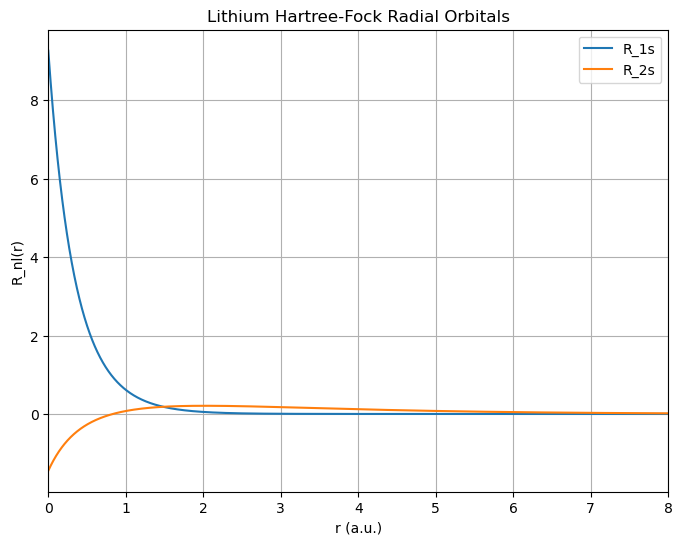

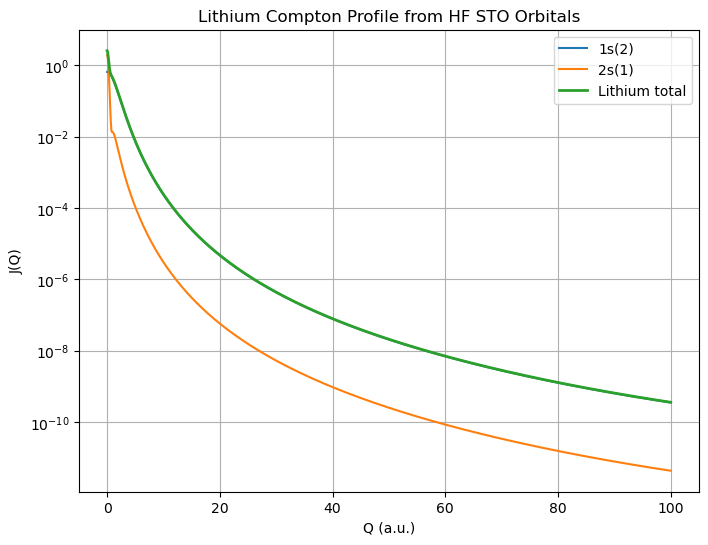

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Lithium Hartree-Fock STO data
# Li: 1s(2) 2s(1)
# Format: (n_j, Z_j, C_j)
# =====================================================

lithium_1s = [
    (1, 4.3069,  0.141279),
    (1, 2.4573,  0.874231),
    (3, 6.7850, -0.005201),
    (2, 7.4527, -0.002307),
    (2, 1.8504,  0.006985),
    (2, 0.7667, -0.000305),
    (2, 0.6364,  0.000760),
]

lithium_2s = [
    (1, 4.3069, -0.022416),
    (1, 2.4573, -0.135791),
    (3, 6.7850, -0.000389),
    (2, 7.4527, -0.000068),
    (2, 1.8504, -0.076544),
    (2, 0.7667,  0.340542),
    (2, 0.6364,  0.715708),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 2000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Lithium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        
R1s = R_nl(r, lithium_1s)
R2s = R_nl(r, lithium_2s)

print_R_formula(lithium_1s, "Li_R1s")
print_R_formula(lithium_2s, "Li_R2s")


# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)


# Carbon has 1s2 2s1
J_total = 2*J_1s + J_2s

# =====================================================
# Print and save table
# =====================================================

table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_1s(2)": 2*J_1s,
    "J_2s(1)": 1*J_2s,
    "J_total_carbon": J_total
})

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.6e}".format)

print(table)

table.to_csv("Lithium_HF_Compton_profile.csv", index=False)
print("\nSaved: Lithium_HF1_Compton_profile.csv")

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Lithium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 1*J_2s, label="2s(1)")
plt.plot(Q, J_total, label="Lithium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Lithium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()